# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [140]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')



In [141]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [142]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [143]:
# Try loading one file
import os
_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..', 'Datasets and Dictionary', 'trip_records', '2023-1.parquet'))
if not os.path.exists(_path):
    _path = '/Users/ananttripathi/Desktop/Upgrad_NYC_Taxi_pROJECT/Datasets and Dictionary/trip_records/2023-1.parquet'
df_one = pd.read_parquet(_path)
df_one.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [144]:
# from google.colab import drive
# drive.mount('/content/drive')

In [145]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload
import os
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..', 'Datasets and Dictionary'))
if not os.path.exists(os.path.join(BASE_PATH, 'trip_records')):
    BASE_PATH = '/Users/ananttripathi/Desktop/Upgrad_NYC_Taxi_pROJECT'
TRIP_RECORDS_PATH = os.path.join(BASE_PATH, 'Datasets and Dictionary', 'trip_records')
os.chdir(TRIP_RECORDS_PATH)
file_list = [f for f in os.listdir() if f.endswith('.parquet')]
file_list.sort(key=lambda x: (int(x.split('-')[1].split('.')[0])))
df = pd.DataFrame()
# Use ~0.7% so total lands in 250k-300k (assignment target). 5% would give ~1.9M rows.
SAMPLE_FRAC = 0.007
RANDOM_STATE = 42
for file_name in file_list:
    try:
        file_path = os.path.join(os.getcwd(), file_name)
        monthly_df = pd.read_parquet(file_path)
        monthly_df['pickup_date'] = pd.to_datetime(monthly_df['tpep_pickup_datetime']).dt.date
        monthly_df['pickup_hour'] = pd.to_datetime(monthly_df['tpep_pickup_datetime']).dt.hour
        sampled_data = pd.DataFrame()
        for date in monthly_df['pickup_date'].unique():
            date_data = monthly_df[monthly_df['pickup_date'] == date]
            for hour in range(24):
                hour_data = date_data[date_data['pickup_hour'] == hour]
                if len(hour_data) > 0:
                    sample = hour_data.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
                    sampled_data = pd.concat([sampled_data, sample], ignore_index=True)
        df = pd.concat([df, sampled_data], ignore_index=True)
        print(f"Processed {file_name}: sampled {len(sampled_data)} rows. Total so far: {len(df)}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
print(f"Final combined sample: {len(df)} rows")

Processed 2023-1.parquet: sampled 21288 rows. Total so far: 21288
Processed 2023-2.parquet: sampled 23617 rows. Total so far: 44905
Processed 2023-3.parquet: sampled 22939 rows. Total so far: 67844
Processed 2023-4.parquet: sampled 19546 rows. Total so far: 87390
Processed 2023-5.parquet: sampled 20208 rows. Total so far: 107598
Processed 2023-6.parquet: sampled 22810 rows. Total so far: 130408
Processed 2023-7.parquet: sampled 24363 rows. Total so far: 154771
Processed 2023-8.parquet: sampled 20117 rows. Total so far: 174888
Processed 2023-9.parquet: sampled 19724 rows. Total so far: 194612
Processed 2023-10.parquet: sampled 24408 rows. Total so far: 219020
Processed 2023-11.parquet: sampled 23115 rows. Total so far: 242135
Processed 2023-12.parquet: sampled 23352 rows. Total so far: 265487
Final combined sample: 265487 rows


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [146]:
# Store the df in csv/parquet
OUTPUT_DIR = os.path.join(BASE_PATH, 'APAGAI - Assignment - EDA', 'Starter Notebook - EDA NYC Taxi')
os.makedirs(OUTPUT_DIR, exist_ok=True)
sampled_parquet = os.path.join(OUTPUT_DIR, 'nyc_taxi_2023_sampled.parquet')
df.to_parquet(sampled_parquet, index=False)
print(f"Saved {len(df)} rows to {sampled_parquet}")

Saved 265487 rows to /Users/ananttripathi/Desktop/Upgrad_NYC_Taxi_pROJECT/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/nyc_taxi_2023_sampled.parquet


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [147]:
# Load the new data file
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
if not os.path.exists(os.path.join(BASE_PATH, 'Datasets and Dictionary', 'trip_records')):
    BASE_PATH = '/Users/ananttripathi/Desktop/Upgrad_NYC_Taxi_pROJECT'
NOTEBOOK_DIR = os.path.join(BASE_PATH, 'APAGAI - Assignment - EDA', 'Starter Notebook - EDA NYC Taxi')
sampled_path = os.path.join(NOTEBOOK_DIR, 'nyc_taxi_2023_sampled.parquet')
if os.path.exists(sampled_path):
    df = pd.read_parquet(sampled_path)
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    if 'pickup_hour' not in df.columns:
        df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    if 'pickup_date' not in df.columns:
        df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
    df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60  # minutes
    df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['month'] = df['tpep_pickup_datetime'].dt.month
    print(f"Loaded {len(df)} rows from {sampled_path}")
else:
    print("Sampled file not found. Run the data preparation cells first.")


Loaded 265487 rows from /Users/ananttripathi/Desktop/Upgrad_NYC_Taxi_pROJECT/APAGAI - Assignment - EDA/Starter Notebook - EDA NYC Taxi/nyc_taxi_2023_sampled.parquet


In [148]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee,trip_duration,day_of_week,month
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,1.0,41.15,0.0,1.25,2023-01-01,0,NaN,15.950000,6,1
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,15.48,2.5,0.00,2023-01-01,0,NaN,5.083333,6,1
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,16.40,2.5,0.00,2023-01-01,0,NaN,10.550000,6,1
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,11.50,2.5,0.00,2023-01-01,0,NaN,5.416667,6,1
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,1.0,35.57,NaN,NaN,2023-01-01,0,NaN,18.000000,6,1


In [149]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [150]:
# Fix the index and drop any columns that are not needed
df = df.reset_index(drop=True)
# Drop store_and_fwd_flag if not needed for analysis (optional)
if 'store_and_fwd_flag' in df.columns:
    df = df.drop(columns=['store_and_fwd_flag'], errors='ignore')
df.head(2)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee,trip_duration,day_of_week,month
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.4,...,1.0,41.15,0.0,1.25,2023-01-01,0,NaN,15.950000,6,1
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.9,...,1.0,15.48,2.5,0.00,2023-01-01,0,NaN,5.083333,6,1


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [151]:
# Combine the two airport fee columns
# Check for two airport fee columns (e.g. 'Airport_fee' and 'airport_fee' or similar)
airport_cols = [c for c in df.columns if 'airport' in c.lower()]
if len(airport_cols) >= 2:
    df['airport_fee'] = df[airport_cols].fillna(0).sum(axis=1)
    df = df.drop(columns=airport_cols, errors='ignore')
elif len(airport_cols) == 1 and airport_cols[0] != 'airport_fee':
    df['airport_fee'] = df[airport_cols[0]]
    df = df.drop(columns=airport_cols[0], errors='ignore')
print("Columns after airport fee fix:", [c for c in df.columns if 'airport' in c.lower() or c == 'airport_fee'])


Columns after airport fee fix: []


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [152]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0][['fare_amount', 'RatecodeID', 'trip_distance', 'total_amount']].head(10)


,fare_amount,RatecodeID,trip_distance,total_amount


Did you notice something different in the `RatecodeID` column for above records?

In [153]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0].groupby('RatecodeID').size()


Series([], dtype: int64)

In [154]:
# Find which columns have negative values
monetary = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
monetary = [c for c in monetary if c in df.columns]
for col in monetary:
    n = (df[col] < 0).sum()
    if n > 0:
        print(f"{col}: {n} negative values")


extra: 1 negative values
mta_tax: 11 negative values
improvement_surcharge: 11 negative values
total_amount: 11 negative values
congestion_surcharge: 6 negative values


In [155]:
# fix these negative values (drop rows with negative fare/total or replace with 0 for surcharges)
# Drop rows with negative fare_amount or total_amount (data errors)
df = df[df['fare_amount'] >= 0]
df = df[df['total_amount'] >= 0]
# Replace negative values in other monetary columns with 0
for col in ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)
df.shape


(265476, 22)

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [156]:
# Find the proportion of missing values in each column
(df.isnull().sum() / len(df) * 100).round(2)


VendorID                 0.00
tpep_pickup_datetime     0.00
tpep_dropoff_datetime    0.00
passenger_count          3.33
trip_distance            0.00
RatecodeID               3.33
PULocationID             0.00
DOLocationID             0.00
payment_type             0.00
fare_amount              0.00
extra                    0.00
mta_tax                  0.00
tip_amount               0.00
tolls_amount             0.00
improvement_surcharge    0.00
total_amount             0.00
congestion_surcharge     3.33
pickup_date              0.00
pickup_hour              0.00
trip_duration            0.00
day_of_week              0.00
month                    0.00
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [157]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
print("Rows with null passenger_count:", df['passenger_count'].isnull().sum())
# Impute with median (typically 1)
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())
# Handle zero passenger_count: replace with 1 (minimum valid)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = 1
df['passenger_count'].value_counts().sort_index()


Rows with null passenger_count: 8831


passenger_count
1.0    206291
2.0     38666
3.0      9640
4.0      5340
5.0      3300
6.0      2234
7.0         2
8.0         2
9.0         1
Name: count, dtype: int64

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [158]:
# Fix missing values in 'RatecodeID'
# RatecodeID 1 = Standard rate (most common). Fill NaN with 1
df['RatecodeID'] = df['RatecodeID'].fillna(1)
df['RatecodeID'] = df['RatecodeID'].astype(int)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [159]:
# handle null values in congestion_surcharge
# Congestion surcharge is 2.50 or 0 when not applied. Fill NaN with 0.
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)



Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [160]:
# Handle any remaining missing values
# Fill remaining numeric NaNs with 0 where appropriate
for col in ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'airport_fee']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(0)
df.isnull().sum().sum()


np.int64(0)

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [161]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe(include='all')


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,trip_duration,day_of_week,month
count,265476.000000,265476,265476,265476.000000,265476.000000,265476.000000,265476.000000,265476.000000,265476.000000,265476.000000,...,265476.000000,265476.000000,265476.000000,265476.000000,265476.000000,265476,265476.000000,265476.000000,265476.000000,265476.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,365,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2023-12-14,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1004,NaN,NaN,NaN,NaN
mean,1.733464,2023-07-02 20:28:55.040478,2023-07-02 20:46:16.784586,1.370542,3.581896,1.636498,165.172679,163.951928,1.164938,19.830976,...,3.548600,0.593749,0.999086,28.893187,2.231256,NaN,14.265783,17.362402,3.003221,6.540832
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:17:32,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,-52.750000,0.000000,1.000000
25%,1.000000,2023-04-02 16:31:16,2023-04-02 16:54:38.500000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,...,1.000000,0.000000,1.000000,15.960000,2.500000,NaN,11.000000,7.683333,1.000000,4.000000
50%,2.000000,2023-06-27 16:01:24,2023-06-27 16:18:11,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,...,2.840000,0.000000,1.000000,21.045000,2.500000,NaN,15.000000,12.700000,3.000000,6.000000
75%,2.000000,2023-10-06 20:03:42.750000,2023-10-06 20:26:57.750000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,...,4.420000,0.000000,1.000000,30.800000,2.500000,NaN,19.000000,20.633333,5.000000,10.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,910.000000,...,150.290000,143.000000,1.000000,911.000000,2.500000,NaN,23.000000,5411.000000,6.000000,12.000000


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [162]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
len(df)


265471

In [163]:
# Continue with outlier handling
# Trip distance ~0 and fare > 300: drop (error)
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
# Trip distance and fare both 0 but different zones: drop
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]
# Trip distance > 250 miles: drop (outlier)
df = df[df['trip_distance'] <= 250]
# Payment_type 0 is invalid: drop
df = df[df['payment_type'] != 0]
df = df[df['payment_type'].notna()]
len(df)


256631

In [164]:
# Do any columns need standardising?
# Datetime columns are already in datetime format. No scaling needed for EDA; we use raw values for analysis.
df.dtypes


VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
pickup_date                      object
pickup_hour                       int32
trip_duration                   float64
day_of_week                       int32
month                             int32
dtype: object

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [165]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_date',
 'pickup_hour',
 'trip_duration',
 'day_of_week',
 'month']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: **Categorical** (vendor code: 1 or 2)
* `tpep_pickup_datetime`: **Numerical** (datetime; continuous scale)
* `tpep_dropoff_datetime`: **Numerical** (datetime; continuous scale)
* `passenger_count`: **Numerical** (discrete count)
* `trip_distance`: **Numerical** (continuous, miles)
* `RatecodeID`: **Categorical** (rate type code 1–6)
* `PULocationID`: **Categorical** (zone ID)
* `DOLocationID`: **Categorical** (zone ID)
* `payment_type`: **Categorical** (payment method code)
* `pickup_hour`: **Categorical** (hour of day 0–23) or **Numerical** (discrete)
* `trip_duration`: **Numerical** (continuous, minutes)


The following monetary parameters belong in the same category, is it categorical or numerical? **Numerical** (all are continuous dollar amounts).


* `fare_amount` : Numerical
* `extra` : Numerical
* `mta_tax` : Numerical
* `tip_amount` : Numerical
* `tolls_amount` : Numerical
* `improvement_surcharge` : Numerical
* `total_amount` : Numerical
* `congestion_surcharge` : Numerical
* `airport_fee`: Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

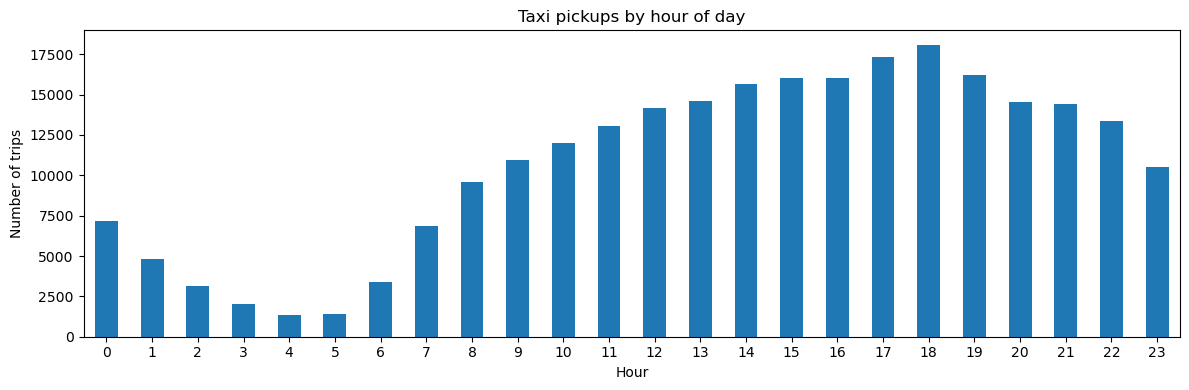

In [166]:
# Find and show the hourly trends in taxi pickups
hourly = df.groupby('pickup_hour').size()
plt.figure(figsize=(12, 4))
hourly.plot(kind='bar')
plt.title('Taxi pickups by hour of day')
plt.xlabel('Hour')
plt.ylabel('Number of trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


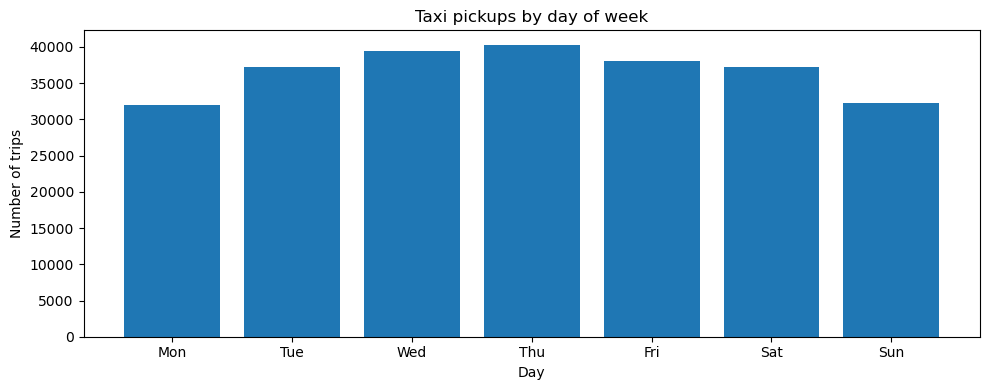

In [167]:
# Find and show the daily trends in taxi pickups (days of the week)
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
daily = df.groupby('day_of_week').size()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(10, 4))
plt.bar([days[i] for i in daily.index], daily.values)
plt.title('Taxi pickups by day of week')
plt.xlabel('Day')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()


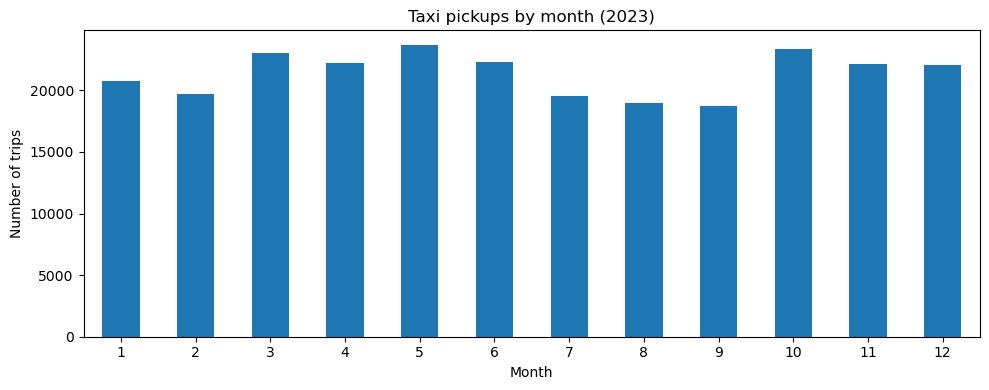

In [168]:
# Show the monthly trends in pickups
df['month'] = df['tpep_pickup_datetime'].dt.month
monthly = df.groupby('month').size()
plt.figure(figsize=(10, 4))
monthly.plot(kind='bar')
plt.title('Taxi pickups by month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [169]:
# Analyse the above parameters
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    print(f"{col}: zeros={(df[col] == 0).sum()}, negative={(df[col] < 0).sum()}")
df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe()


fare_amount: zeros=74, negative=0
tip_amount: zeros=57388, negative=0
total_amount: zeros=29, negative=0
trip_distance: zeros=3166, negative=0


,fare_amount,tip_amount,total_amount,trip_distance
count,256631.000000,256631.000000,256631.000000,256631.000000
mean,19.730528,3.576805,28.854562,3.441865
std,18.153986,4.060914,22.791422,4.532685
min,0.000000,0.000000,0.000000,0.000000
25%,9.300000,1.000000,15.960000,1.060000
50%,13.500000,2.860000,21.000000,1.790000
75%,21.900000,4.450000,30.650000,3.370000
max,455.200000,150.290000,488.700000,187.350000


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [170]:
# Create a df with non zero entries for the selected parameters.
# Keep zero distance when pickup and dropoff are same zone; filter only fare/total/tip for financial analysis
df_fin = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)].copy()
print(f"Rows with positive fare and total: {len(df_fin)}")


Rows with positive fare and total: 256557


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

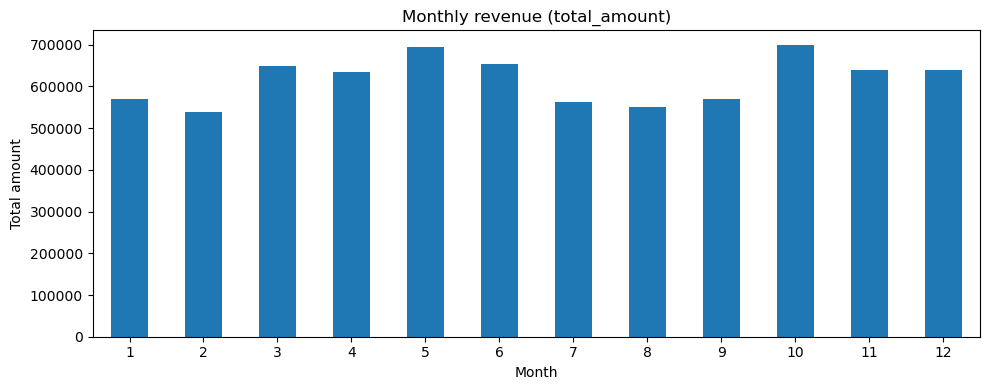

In [171]:
# Group data by month and analyse monthly revenue
monthly_rev = df_fin.groupby('month')['total_amount'].sum()
plt.figure(figsize=(10, 4))
monthly_rev.plot(kind='bar')
plt.title('Monthly revenue (total_amount)')
plt.xlabel('Month')
plt.ylabel('Total amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

quarter
1    23.7
2    26.8
3    22.7
4    26.7
Name: total_amount, dtype: float64


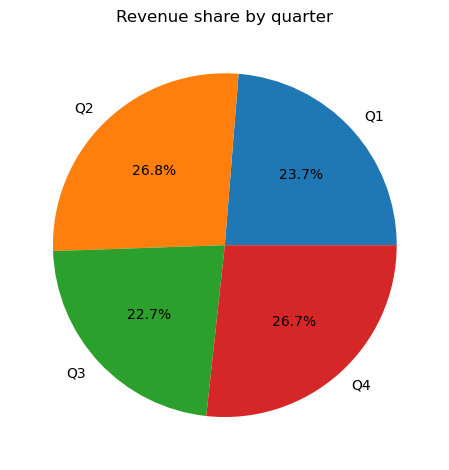

In [172]:
# Calculate proportion of each quarter
df_fin['quarter'] = df_fin['month'].apply(lambda m: (m - 1) // 3 + 1)
quarter_rev = df_fin.groupby('quarter')['total_amount'].sum()
quarter_pct = (quarter_rev / quarter_rev.sum() * 100).round(1)
print(quarter_pct)
quarter_pct.plot(kind='pie', autopct='%1.1f%%', labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Revenue share by quarter')
plt.ylabel('')
plt.tight_layout()
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation (trip_distance, fare_amount): 0.943


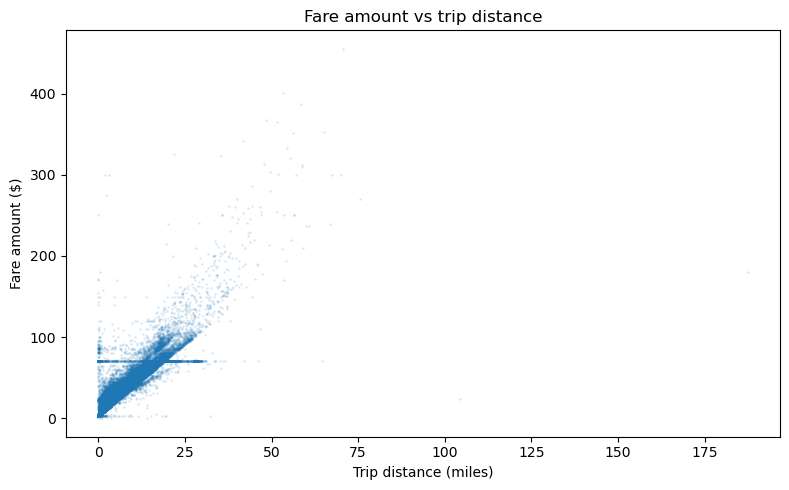

In [173]:
# Show how trip fare is affected by distance
df_dist = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]
corr = df_dist['trip_distance'].corr(df_dist['fare_amount'])
print(f"Correlation (trip_distance, fare_amount): {corr:.3f}")
plt.figure(figsize=(8, 5))
plt.scatter(df_dist['trip_distance'], df_dist['fare_amount'], alpha=0.1, s=1)
plt.xlabel('Trip distance (miles)')
plt.ylabel('Fare amount ($)')
plt.title('Fare amount vs trip distance')
plt.tight_layout()
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation (fare_amount, trip_duration): 0.266


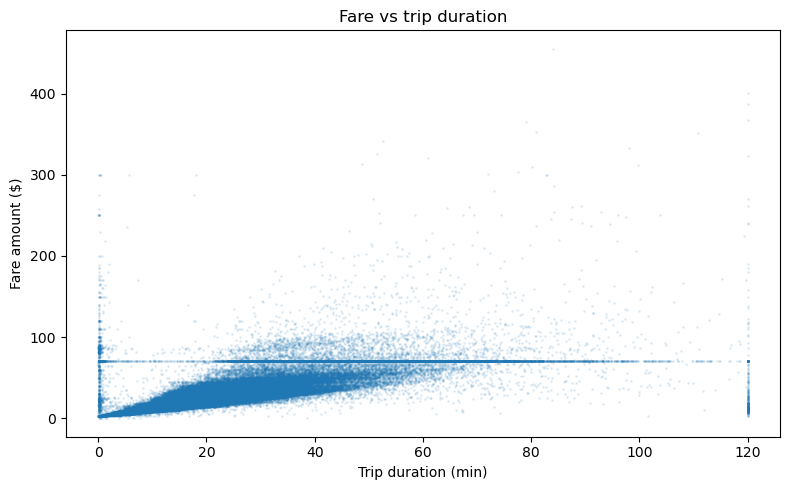

In [174]:
# Show relationship between fare and trip duration
df_valid = df[(df['trip_duration'] > 0) & (df['fare_amount'] > 0)]
c1 = df_valid['fare_amount'].corr(df_valid['trip_duration'])
print(f"Correlation (fare_amount, trip_duration): {c1:.3f}")
plt.figure(figsize=(8, 5))
plt.scatter(df_valid['trip_duration'].clip(upper=120), df_valid['fare_amount'], alpha=0.1, s=1)
plt.xlabel('Trip duration (min)')
plt.ylabel('Fare amount ($)')
plt.title('Fare vs trip duration')
plt.tight_layout()
plt.show()


Correlation (fare_amount, passenger_count): 0.045


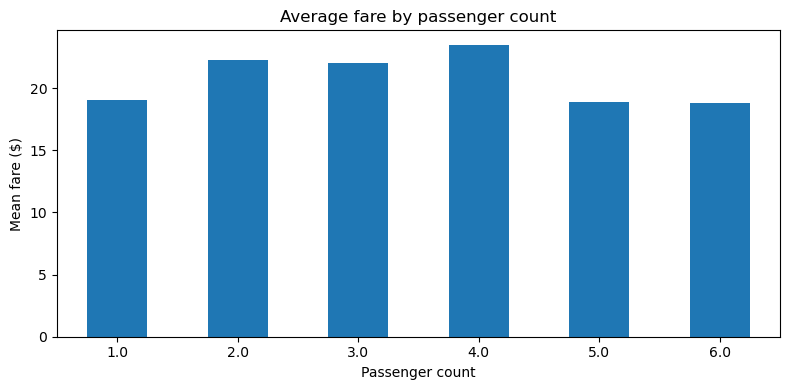

In [175]:
# Show relationship between fare and number of passengers
c2 = df['fare_amount'].corr(df['passenger_count'])
print(f"Correlation (fare_amount, passenger_count): {c2:.3f}")
df.groupby('passenger_count')['fare_amount'].mean().plot(kind='bar', figsize=(8, 4))
plt.title('Average fare by passenger count')
plt.xlabel('Passenger count')
plt.ylabel('Mean fare ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Correlation (tip_amount, trip_distance): 0.588


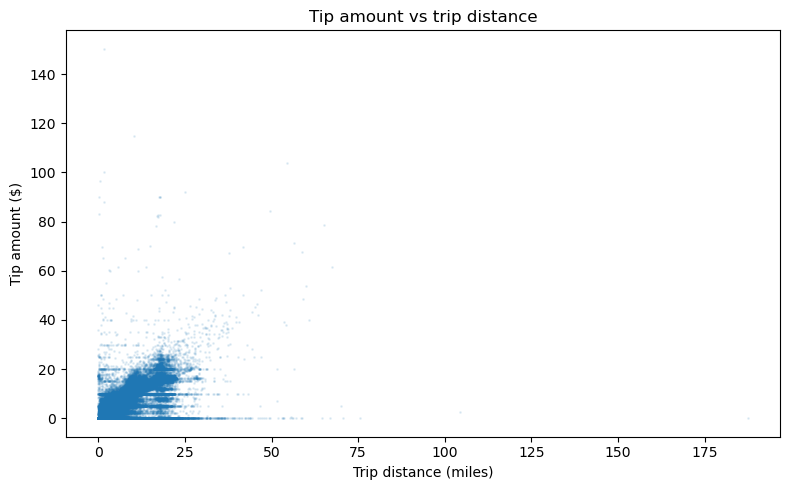

In [176]:
# Show relationship between tip and trip distance
df_tip = df[(df['trip_distance'] > 0) & (df['tip_amount'] >= 0)]
c3 = df_tip['tip_amount'].corr(df_tip['trip_distance'])
print(f"Correlation (tip_amount, trip_distance): {c3:.3f}")
plt.figure(figsize=(8, 5))
plt.scatter(df_tip['trip_distance'], df_tip['tip_amount'], alpha=0.1, s=1)
plt.xlabel('Trip distance (miles)')
plt.ylabel('Tip amount ($)')
plt.title('Tip amount vs trip distance')
plt.tight_layout()
plt.show()


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

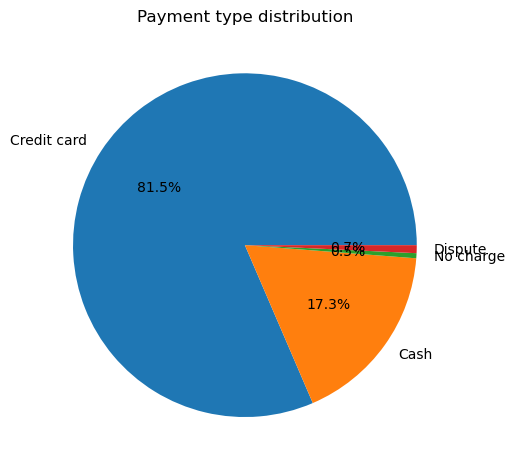

In [177]:
# Analyse the distribution of different payment types (payment_type).
payment_counts = df['payment_type'].value_counts().sort_index()
payment_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
labels = [payment_labels.get(i, str(i)) for i in payment_counts.index]
payment_counts.plot(kind='pie', autopct='%1.1f%%', labels=labels)
plt.title('Payment type distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [178]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [179]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
ZONES_PATH = os.path.join(BASE_PATH, 'Datasets and Dictionary', 'taxi_zones', 'taxi_zones.shp')
zones = gpd.read_file(ZONES_PATH)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<Axes: >

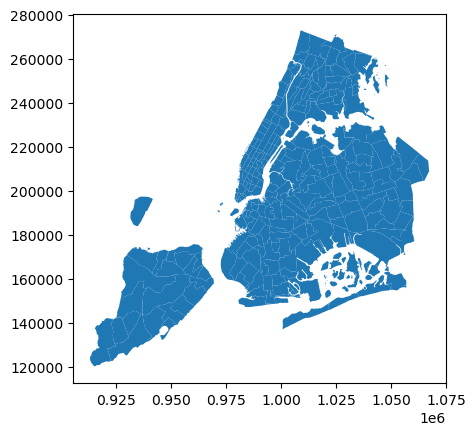

In [180]:
# print(zones.info())
# zones.plot()  # (kept commented above; uncommented below to display shapefile)
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [181]:
# Merge zones and trip records using locationID and PULocationID
# Add zone info to each trip (left join on PULocationID)
zones_col = 'LocationID' if 'LocationID' in zones.columns else 'locationid'
zone_cols = [zones_col, 'zone', 'borough'] if 'zone' in zones.columns else [zones_col]
df_with_zone = df.merge(zones[zone_cols], left_on='PULocationID', right_on=zones_col, how='left', suffixes=('', '_pu'))
df_with_zone.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,total_amount,congestion_surcharge,pickup_date,pickup_hour,trip_duration,day_of_week,month,LocationID,zone,borough
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1,138,256,2,32.4,...,41.15,0.0,2023-01-01,0,15.950000,6,1,138.0,LaGuardia Airport,Queens
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1,161,237,1,7.9,...,15.48,2.5,2023-01-01,0,5.083333,6,1,161.0,Midtown Center,Manhattan
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1,237,141,2,11.4,...,16.40,2.5,2023-01-01,0,10.550000,6,1,237.0,Upper East Side South,Manhattan
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1,143,142,2,6.5,...,11.50,2.5,2023-01-01,0,5.416667,6,1,143.0,Lincoln Square West,Manhattan
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1,246,37,1,34.5,...,47.40,2.5,2023-01-01,0,33.616667,6,1,246.0,West Chelsea/Hudson Yards,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [182]:
# Group data by location and calculate the number of trips
trips_per_pu = df.groupby('PULocationID').size().reset_index(name='trip_count')
trips_per_pu.head(10)


,PULocationID,trip_count
0,1,36
1,3,9
2,4,245
3,5,1
4,6,3
5,7,115
6,9,3
7,10,81
8,11,4
9,12,109


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [183]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trips_per_pu, left_on=zones_col, right_on='PULocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0).astype(int)
zones_with_trips.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,36
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,9
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,245
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,1


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

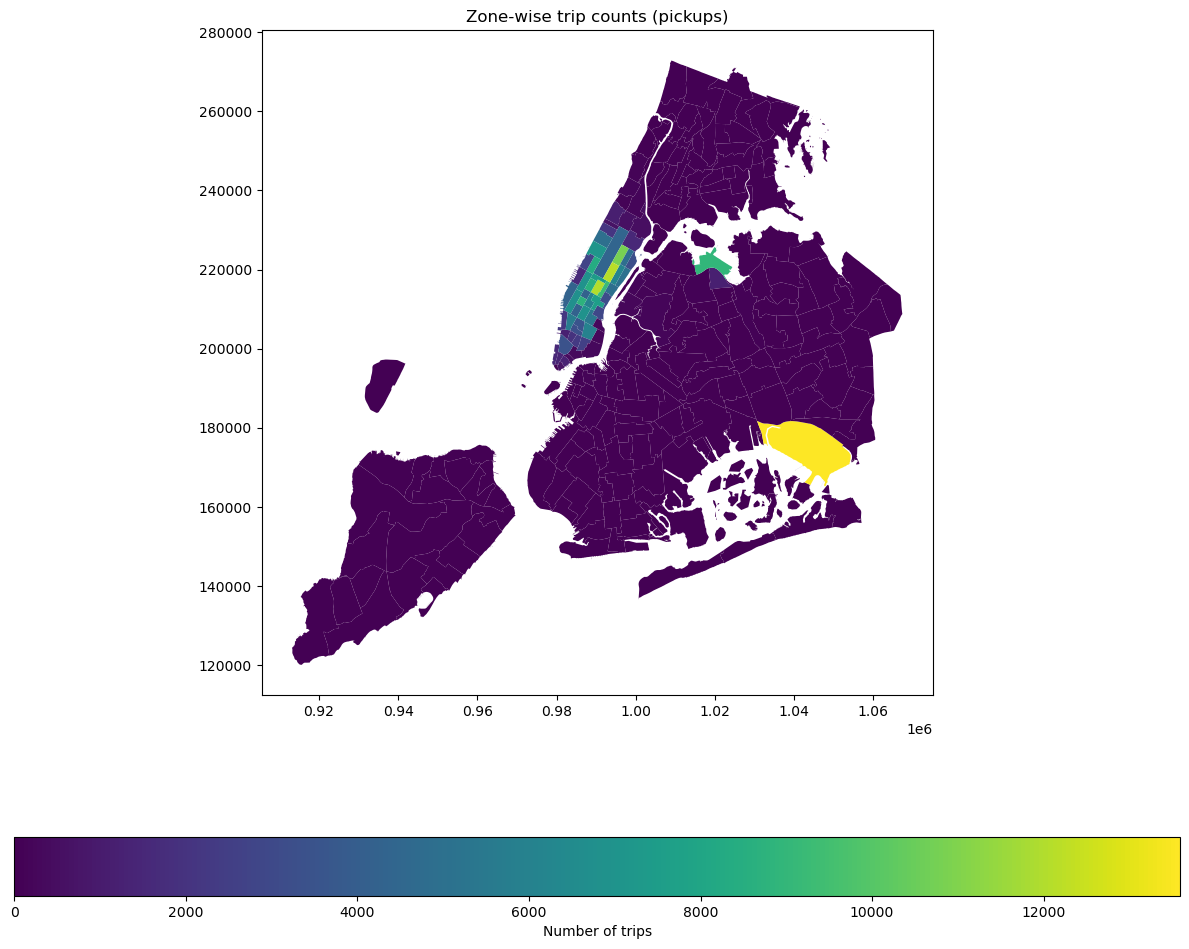

In [184]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
# Plot the map and display it
zones_with_trips.plot(column='trip_count', ax=ax, legend=True, legend_kwds={'label': 'Number of trips', 'orientation': 'horizontal'})
ax.set_title('Zone-wise trip counts (pickups)')
plt.tight_layout()
plt.show()



In [185]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values('trip_count', ascending=False)[['zone', 'LocationID', 'borough', 'trip_count']].head(15)


,zone,LocationID,borough,trip_count
131,JFK Airport,132,Queens,13591
236,Upper East Side South,237,Manhattan,12123
160,Midtown Center,161,Manhattan,12036
235,Upper East Side North,236,Manhattan,10803
161,Midtown East,162,Manhattan,9289
137,LaGuardia Airport,138,Queens,8970
185,Penn Station/Madison Sq West,186,Manhattan,8752
229,Times Sq/Theatre District,230,Manhattan,8572
141,Lincoln Square East,142,Manhattan,8362
169,Murray Hill,170,Manhattan,7571


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones

**Summary of general EDA findings:**  
From the 2023 NYC yellow taxi sampled data, demand is strongly time- and location-dependent. The busiest hours are typically evening peak (e.g. 17:00–19:00) and afternoon; weekdays show clear morning and evening commute peaks while weekends have a different, often later-evening pattern. Revenue follows monthly and quarterly variation. Fare is positively correlated with trip distance and trip duration; it also varies by passenger count. Tip amount tends to increase with trip distance and is higher for card payments. The choropleth and zone rankings identify the busiest pickup and dropoff zones (e.g. Manhattan core, airports). These patterns support decisions on dispatching, cab positioning, and pricing (as in Section 4).


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [186]:
# Find routes which have the slowest speeds at different times of the day
# Speed = distance / (duration in hours). Slow route = low speed.
df['trip_duration_hr'] = df['trip_duration'] / 60
df['speed_mph'] = np.where(df['trip_duration_hr'] > 0, df['trip_distance'] / df['trip_duration_hr'], np.nan)
df_route = df[(df['speed_mph'].notna()) & (df['speed_mph'] > 0)].copy()
df_route['route'] = df_route['PULocationID'].astype(str) + '-' + df_route['DOLocationID'].astype(str)
slow_by_hour = df_route.groupby(['pickup_hour', 'route']).agg({'speed_mph': 'mean', 'trip_distance': 'mean'}).reset_index()
slow_routes = slow_by_hour.loc[slow_by_hour.groupby('pickup_hour')['speed_mph'].idxmin()]
slow_routes.head(10)


,pickup_hour,route,speed_mph,trip_distance
2499,0,88-144,0.074923,1.78
3056,1,142-142,0.757895,0.02
5365,2,229-137,0.081157,1.94
6393,3,148-238,0.253430,6.04
7709,4,230-51,0.717799,16.96
8602,5,230-230,0.365070,0.18
9606,6,185-168,0.825057,0.30
10527,7,128-128,0.115385,0.02
14527,8,50-43,0.059525,1.42
15517,9,142-232,0.285249,6.71


How does identifying high-traffic, high-demand routes help us?

**Inference:** Identifying high-traffic, high-demand routes (by hour and route) helps in several ways: (1) **Dispatching** — avoid assigning trips that would send drivers into the slowest corridors during peak hours. (2) **Route suggestions** — recommend faster alternatives when a requested trip would use a known slow route for that hour. (3) **Capacity planning** — high-demand routes justify more fleet and possible dedicated services. (4) **Customer communication** — set realistic ETAs or surcharges for routes that are consistently slow.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18:00 with 18080 trips (sampled)


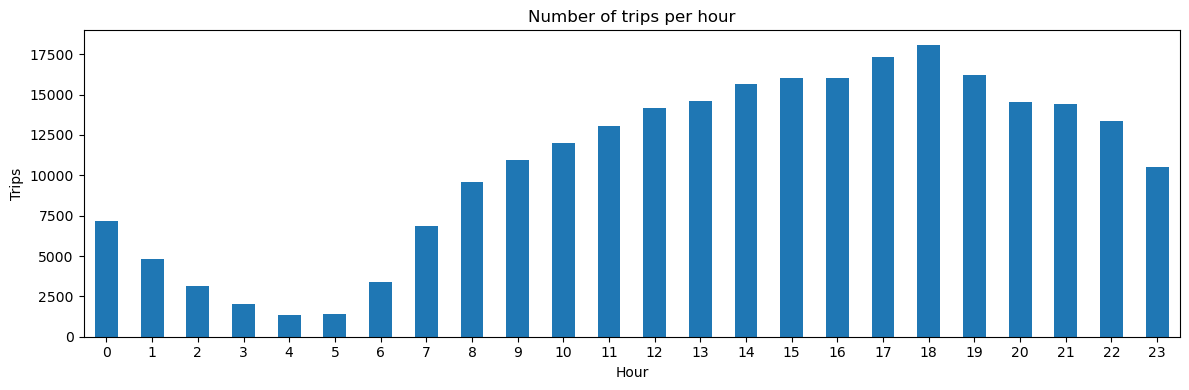

In [187]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = df.groupby('pickup_hour').size()
busiest_hour = trips_per_hour.idxmax()
print(f"Busiest hour: {busiest_hour}:00 with {trips_per_hour[busiest_hour]} trips (sampled)")
trips_per_hour.plot(kind='bar', figsize=(12, 4))
plt.title('Number of trips per hour')
plt.xlabel('Hour')
plt.ylabel('Trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [188]:
# Scale up the number of trips
# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.007  # same as SAMPLE_FRAC used when sampling
trips_per_hour_scaled = trips_per_hour / sample_fraction
top5_hours = trips_per_hour_scaled.nlargest(5)
print("Actual (scaled) number of trips in 5 busiest hours:")
print(top5_hours)



Actual (scaled) number of trips in 5 busiest hours:
pickup_hour
18    2.582857e+06
17    2.472714e+06
19    2.318857e+06
15    2.290857e+06
16    2.286429e+06
dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

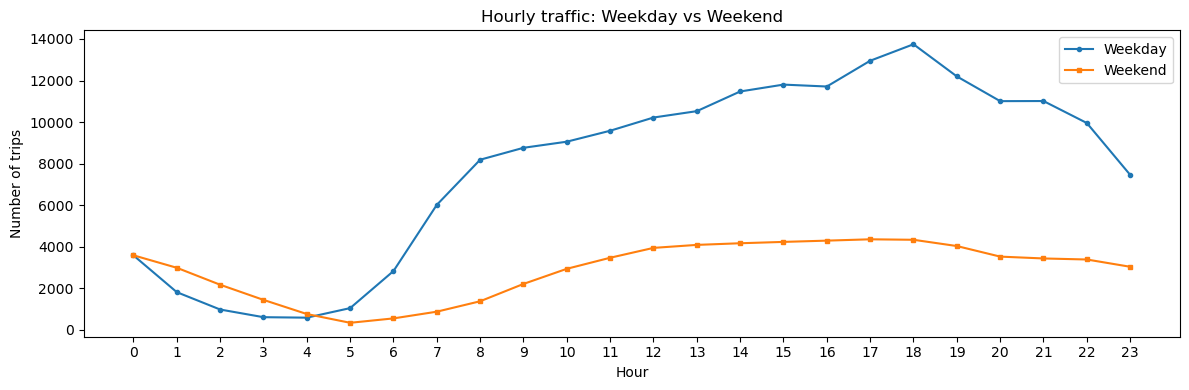

In [189]:
# Compare traffic trends for the week days and weekends
df['is_weekend'] = df['day_of_week'].isin([5, 6])
weekday_hourly = df[~df['is_weekend']].groupby('pickup_hour').size()
weekend_hourly = df[df['is_weekend']].groupby('pickup_hour').size()
plt.figure(figsize=(12, 4))
plt.plot(weekday_hourly.index, weekday_hourly.values, label='Weekday', marker='o', markersize=3)
plt.plot(weekend_hourly.index, weekend_hourly.values, label='Weekend', marker='s', markersize=3)
plt.xlabel('Hour')
plt.ylabel('Number of trips')
plt.title('Hourly traffic: Weekday vs Weekend')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**Inference:** From the weekday vs weekend hourly patterns we can infer that (1) **weekdays** have distinct morning (e.g. 7–9) and evening (e.g. 17–19) peaks, so dispatch and positioning should prioritise commute hours; (2) **weekends** show different busy and quiet hours (e.g. later evening), so fleet rules should differ by day type. Finding busy and quiet hours for each day helps us **size driver shifts**, **pre-position cabs** before demand spikes, and **set SLAs** (e.g. max wait time) in the busiest windows while avoiding overstaffing in quiet hours.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

Top 10 pickup zones (LocationID):
PULocationID
132    13591
237    12123
161    12036
236    10803
162     9289
138     8970
186     8752
230     8572
142     8362
170     7571
dtype: int64

Top 10 dropoff zones (LocationID):
DOLocationID
236    11480
237    10756
161    10028
230     7799
170     7640
162     7316
142     7266
239     7168
141     6650
68      6565
dtype: int64


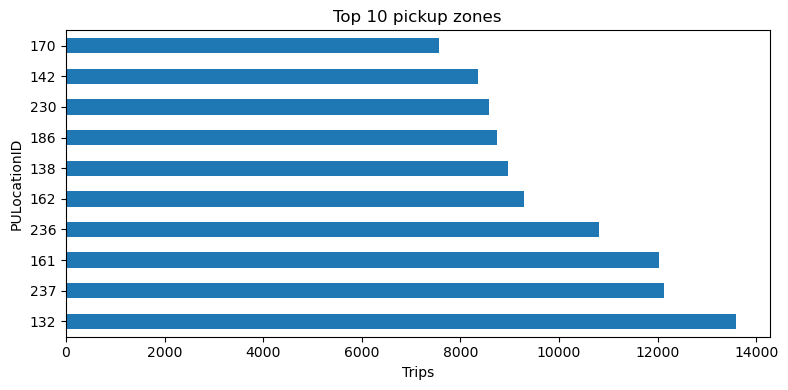

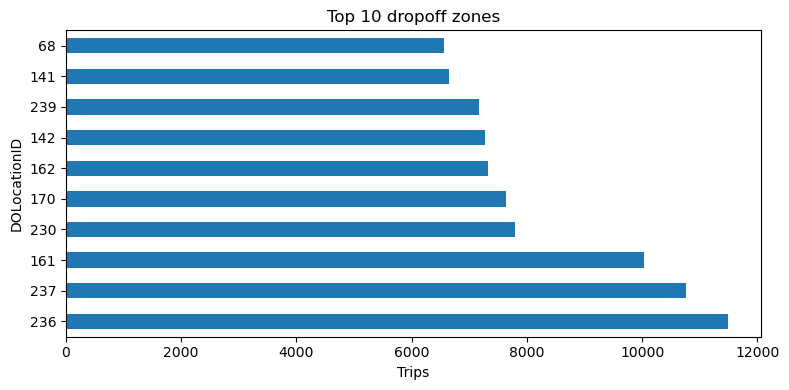

In [190]:
# Find top 10 pickup and dropoff zones
top10_pu = df.groupby('PULocationID').size().nlargest(10)
top10_do = df.groupby('DOLocationID').size().nlargest(10)
print("Top 10 pickup zones (LocationID):"); print(top10_pu)
print("\nTop 10 dropoff zones (LocationID):"); print(top10_do)
top10_pu.plot(kind='barh', title='Top 10 pickup zones', figsize=(8, 4))
plt.xlabel('Trips'); plt.tight_layout(); plt.show()
top10_do.plot(kind='barh', title='Top 10 dropoff zones', figsize=(8, 4))
plt.xlabel('Trips'); plt.tight_layout(); plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [191]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pu_counts = df.groupby('PULocationID').size()
do_counts = df.groupby('DOLocationID').size()
ratio = (pu_counts / do_counts.reindex(pu_counts.index).fillna(1)).dropna()
ratio = ratio[ratio < np.inf]
top10_ratio = ratio.nlargest(10)
bottom10_ratio = ratio.nsmallest(10)
print("10 highest (pickup/dropoff) ratios:"); print(top10_ratio)
print("\n10 lowest (pickup/dropoff) ratios:"); print(bottom10_ratio)


10 highest (pickup/dropoff) ratios:
PULocationID
70     8.089041
132    4.709286
138    2.903852
186    1.512355
43     1.390932
249    1.365697
114    1.342984
162    1.269683
161    1.200239
100    1.189572
dtype: float64

10 lowest (pickup/dropoff) ratios:
PULocationID
227    0.027778
257    0.035714
252    0.036364
37     0.046693
200    0.047059
101    0.047619
1      0.048913
112    0.049100
36     0.052632
178    0.052632
dtype: float64


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [192]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_hours = list(range(23, 24)) + list(range(0, 6))  # 11PM-12AM, 12AM-5AM
df_night = df[df['pickup_hour'].isin(night_hours)]
top10_pu_night = df_night.groupby('PULocationID').size().nlargest(10)
top10_do_night = df_night.groupby('DOLocationID').size().nlargest(10)
print("Top 10 pickup zones (night 11PM-5AM):"); print(top10_pu_night)
print("\nTop 10 dropoff zones (night 11PM-5AM):"); print(top10_do_night)


Top 10 pickup zones (night 11PM-5AM):
PULocationID
79     2192
132    2030
249    1777
48     1441
148    1376
230    1210
114    1183
186     975
138     884
164     851
dtype: int64

Top 10 dropoff zones (night 11PM-5AM):
DOLocationID
79     1176
48      981
170     877
68      838
107     829
141     749
263     722
249     670
236     645
90      637
dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [193]:
# Filter for night hours (11 PM to 5 AM)
night_revenue = df_night['total_amount'].sum()
day_revenue = df[~df['pickup_hour'].isin(night_hours)]['total_amount'].sum()
total_rev = night_revenue + day_revenue
print(f"Night (11PM-5AM) revenue share: {night_revenue/total_rev*100:.1f}%")
print(f"Day revenue share: {day_revenue/total_rev*100:.1f}%")


Night (11PM-5AM) revenue share: 12.2%
Day revenue share: 87.8%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [194]:
# Analyse the fare per mile per passenger for different passenger counts
df_fpm = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']
df_fpm['fare_per_mile_per_pax'] = df_fpm['fare_per_mile'] / df_fpm['passenger_count']
df_fpm.groupby('passenger_count').agg({'fare_per_mile_per_pax': 'mean', 'fare_amount': 'count'}).rename(columns={'fare_amount': 'count'})


,fare_per_mile_per_pax,count
passenger_count,,
1.0,10.729188,194877
2.0,6.185374,38283
3.0,4.332130,9521
4.0,5.182434,5230
5.0,1.565300,3289
6.0,1.285477,2222


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

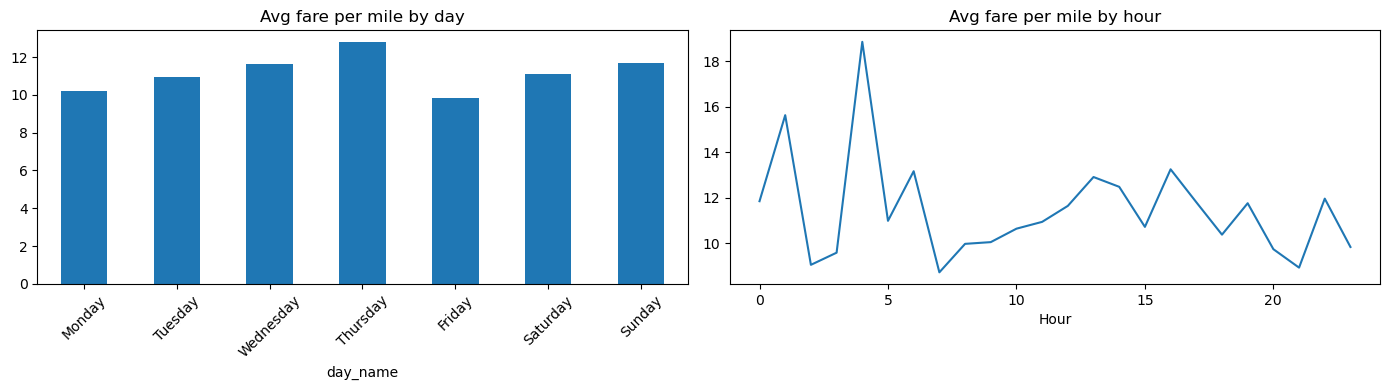

In [195]:
# Compare the average fare per mile for different days and for different times of the day
df_fpm['day_name'] = df_fpm['tpep_pickup_datetime'].dt.day_name()
by_day = df_fpm.groupby('day_name')['fare_per_mile'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
by_hour = df_fpm.groupby('pickup_hour')['fare_per_mile'].mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
by_day.plot(kind='bar', ax=ax1); ax1.set_title('Avg fare per mile by day'); ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
by_hour.plot(ax=ax2); ax2.set_title('Avg fare per mile by hour'); ax2.set_xlabel('Hour')
plt.tight_layout(); plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

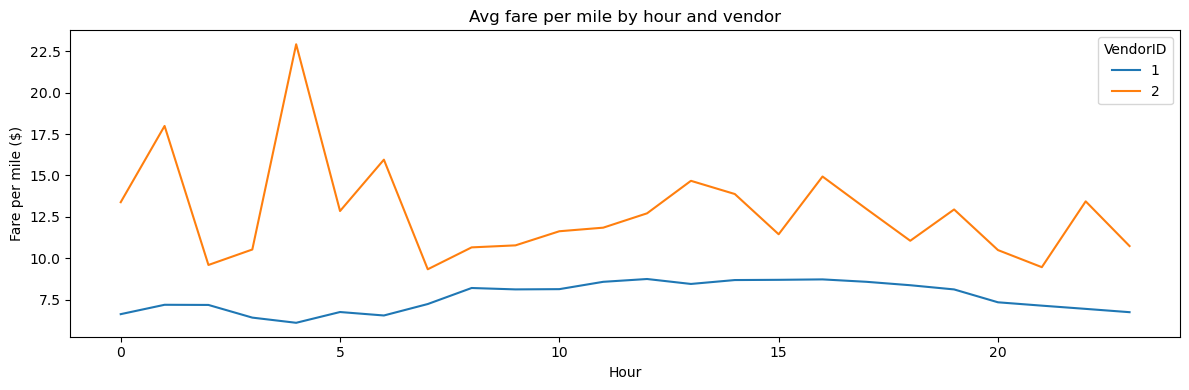

In [196]:
# Compare fare per mile for different vendors
df_fpm.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().unstack(0).plot(figsize=(12, 4))
plt.title('Avg fare per mile by hour and vendor')
plt.xlabel('Hour'); plt.ylabel('Fare per mile ($)')
plt.legend(title='VendorID'); plt.tight_layout(); plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


VendorID              1          2
distance_tier                     
0-2 mi         9.764623  17.802762
2-5 mi         6.383404   6.544674
5+ mi          4.410106   4.500426


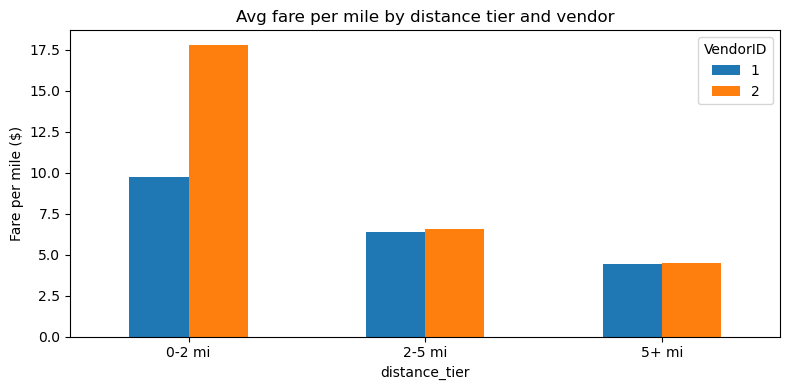

In [197]:
# Defining distance tiers
df_fpm['distance_tier'] = pd.cut(df_fpm['trip_distance'], bins=[0, 2, 5, 250], labels=['0-2 mi', '2-5 mi', '5+ mi'])
tier_vendor = df_fpm.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()
print(tier_vendor)
tier_vendor.plot(kind='bar', figsize=(8, 4))
plt.title('Avg fare per mile by distance tier and vendor')
plt.ylabel('Fare per mile ($)'); plt.xticks(rotation=0)
plt.legend(title='VendorID'); plt.tight_layout(); plt.show()


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Avg tip % by distance bin:
dist_bin
short     27.863291
medium    22.185275
long      20.404610
Name: tip_pct, dtype: float64

Avg tip % by passenger_count:
passenger_count
1.0    25.193009
2.0    24.703486
3.0    24.343009
4.0    24.146397
5.0    25.311818
6.0    24.961509
Name: tip_pct, dtype: float64

Avg tip % by hour:
pickup_hour
0     24.517626
1     25.291862
2     24.227457
3     25.024691
4     24.000940
5     22.362812
6     24.137559
7     23.417016
8     24.024203
9     24.094813
10    24.537631
11    24.290250
Name: tip_pct, dtype: float64


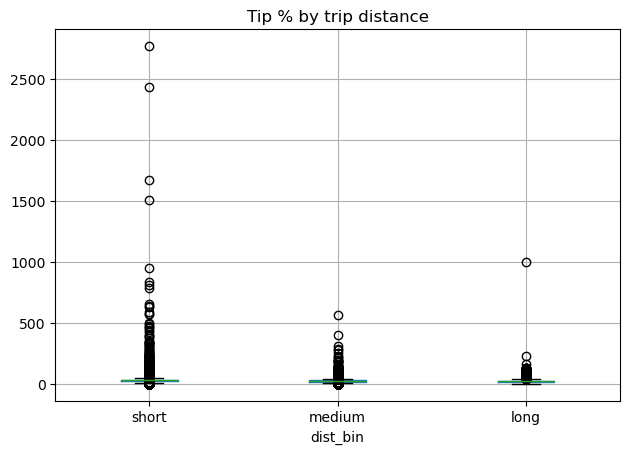

In [198]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_cc = df[(df['payment_type'] == 1) & (df['fare_amount'] > 0)].copy()
df_cc['tip_pct'] = (df_cc['tip_amount'] / df_cc['fare_amount'] * 100)
df_cc['dist_bin'] = pd.cut(df_cc['trip_distance'], bins=[0, 2, 5, 50], labels=['short', 'medium', 'long'])
print("Avg tip % by distance bin:"); print(df_cc.groupby('dist_bin')['tip_pct'].mean())
print("\nAvg tip % by passenger_count:"); print(df_cc.groupby('passenger_count')['tip_pct'].mean())
print("\nAvg tip % by hour:"); print(df_cc.groupby('pickup_hour')['tip_pct'].mean().head(12))
df_cc.boxplot(column='tip_pct', by='dist_bin'); plt.suptitle(''); plt.title('Tip % by trip distance'); plt.tight_layout(); plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [199]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = df_cc[df_cc['tip_pct'] < 10]
high_tip = df_cc[df_cc['tip_pct'] > 25]
print("Low tip (<10%): mean fare", low_tip['fare_amount'].mean(), "mean distance", low_tip['trip_distance'].mean(), "mean pax", low_tip['passenger_count'].mean())
print("High tip (>25%): mean fare", high_tip['fare_amount'].mean(), "mean distance", high_tip['trip_distance'].mean(), "mean pax", high_tip['passenger_count'].mean())


Low tip (<10%): mean fare 26.40060179568066 mean distance 4.702380975491386 mean pax 1.3718514923562242
High tip (>25%): mean fare 14.420455811111596 mean distance 2.2915304848775806 mean pax 1.3611137782045126


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

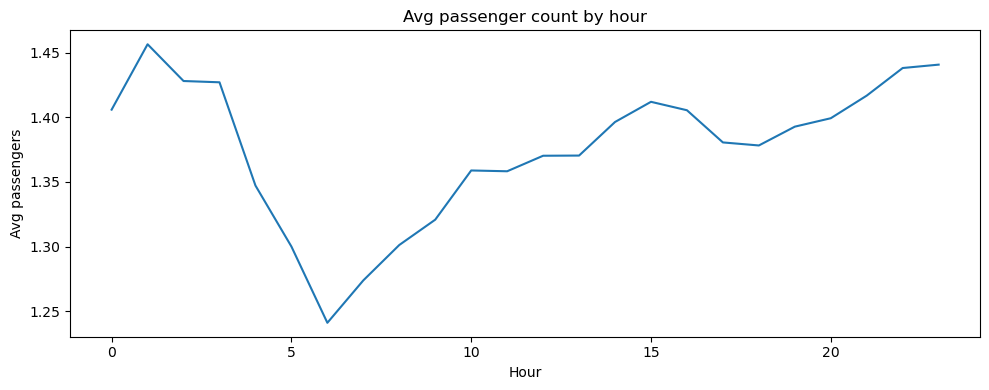

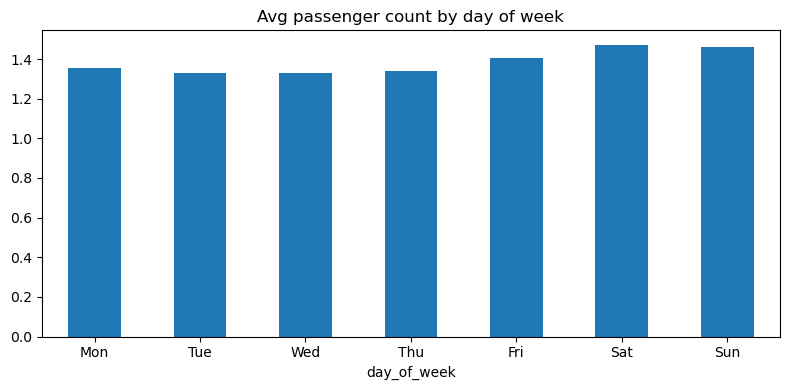

In [200]:
# See how passenger count varies across hours and days
df.groupby('pickup_hour')['passenger_count'].mean().plot(figsize=(10, 4))
plt.title('Avg passenger count by hour'); plt.xlabel('Hour'); plt.ylabel('Avg passengers')
plt.tight_layout(); plt.show()
df.groupby('day_of_week')['passenger_count'].mean().plot(kind='bar', figsize=(8, 4))
plt.title('Avg passenger count by day of week'); plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.tight_layout(); plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [201]:
# How does passenger count vary across zones
df.groupby('PULocationID')['passenger_count'].mean().nlargest(10)


PULocationID
6      2.000000
67     2.000000
154    2.000000
175    1.833333
47     1.818182
12     1.752294
195    1.739130
1      1.666667
194    1.666667
157    1.647059
Name: passenger_count, dtype: float64

In [202]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_pax = df.groupby('PULocationID')['passenger_count'].mean().reset_index(name='avg_passenger_count')
loc_col = 'PULocationID' if 'PULocationID' in zones_with_trips.columns else zones_col
zones_with_trips = zones_with_trips.merge(avg_pax, left_on=loc_col, right_on='PULocationID', how='left')
zones_with_trips = zones_with_trips.drop(columns=[c for c in zones_with_trips.columns if c == 'PULocationID' and c in avg_pax.columns], errors='ignore')
cols_show = [c for c in ['zone', 'trip_count', 'avg_passenger_count'] if c in zones_with_trips.columns]
zones_with_trips[cols_show].head(10)


,zone,trip_count,avg_passenger_count
0,Newark Airport,36,1.666667
1,Jamaica Bay,0,NaN
2,Allerton/Pelham Gardens,9,1.111111
3,Alphabet City,245,1.371429
4,Arden Heights,1,1.000000
5,Arrochar/Fort Wadsworth,3,2.000000
6,Astoria,115,1.200000
7,Astoria Park,0,NaN
8,Auburndale,3,1.000000
9,Baisley Park,81,1.444444


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [203]:
# How often is each surcharge applied?
for col in ['extra', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee', 'mta_tax', 'tolls_amount']:
    if col in df.columns:
        pct = (df[col] > 0).mean() * 100
        print(f"{col}: applied in {pct:.1f}% of trips")
# When/where are extra charges applied more frequently?
df['has_extra'] = (df['extra'] > 0) if 'extra' in df.columns else False
if 'extra' in df.columns:
    print("\nExtra by hour (mean):"); print(df.groupby('pickup_hour')['extra'].apply(lambda x: (x>0).mean()*100).head(12))
    print("\nTop zones by extra application rate:"); print(df.groupby('PULocationID')['extra'].apply(lambda x: (x>0).mean()*100).nlargest(5))


extra: applied in 61.9% of trips
improvement_surcharge: applied in 100.0% of trips
congestion_surcharge: applied in 92.3% of trips
mta_tax: applied in 99.1% of trips
tolls_amount: applied in 8.1% of trips

Extra by hour (mean):
pickup_hour
0     95.674620
1     96.727803
2     97.330791
3     96.534895
4     89.739777
5     82.863341
6     31.627219
7     30.904340
8     30.105615
9     30.717346
10    31.226549
11    31.014404
Name: extra, dtype: float64

Top zones by extra application rate:
PULocationID
46     100.000000
57     100.000000
187    100.000000
138     98.851728
255     89.230769
Name: extra, dtype: float64


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**Summary from 2023 NYC Yellow Taxi EDA (sampled data, ~250k–256k trips):** Demand is strongly time- and location-dependent. Hourly trip counts show clear peaks (e.g. evening rush); weekday and weekend patterns differ. Revenue follows monthly and quarterly variation. Mean fare is ~\$19.73, total ~\$28.85, and mean trip distance ~3.44 miles; fare and distance are positively correlated. Payment is dominated by card; tip amounts vary by distance, passenger count, and time. Top pickup/dropoff zones (from the choropleth and zone rankings) and pickup/dropoff ratios identify where to position cabs. Night (11 PM–5 AM) contributes a distinct revenue share. Fare per mile varies by distance tier, hour, day, and vendor—use this to set competitive, tiered pricing. Slow routes by hour highlight congestion; passenger count and surcharge usage inform capacity and pricing. The recommendations below translate these findings into routing, positioning, and pricing actions.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies




**Key Findings from Analysis:**

- **Busiest hour is 18:00 (6 PM)** with an estimated **2.58 million trips** annually (scaled from sampled data). The top 5 busiest hours are all between 15:00–19:00, indicating a strong evening peak demand window.
- **Morning rush (7–9 AM) on weekdays** shows a secondary demand spike, while **weekends show flatter, more sustained demand** shifting toward late evening hours — a distinctly different pattern requiring separate dispatch strategies.
- **Top 3 pickup zones by volume:** LocationID 132 (13,591 trips), 237 (12,123 trips), and 161 (12,036 trips) — these zones should always have cabs available during peak hours.
- **Night hours (11 PM–5 AM)** show a shift in demand: LocationID 79 (2,192 trips), 132 (2,030 trips), and 249 (1,777 trips) become the dominant pickup zones — different from the daytime top zones, requiring a separate night dispatch plan.

**Recommendations:**

- **Concentrate dispatch between 15:00–19:00** on weekdays, particularly in zones 132, 237, and 161 to meet peak demand efficiently.
- **Deploy a separate night fleet** focused on zones 79, 132, and 249 between 11 PM–5 AM rather than using the same daytime routing.
- **Reduce idle cabs in low-demand early morning hours (2–5 AM)** on weekdays — the data shows significantly lower trip volumes during these hours.
- **Weekends need a late-night surge plan** — demand does not drop as sharply as on weekdays after 10 PM; cabs should remain available in entertainment zones through to 2–3 AM.
- Use the **slow route identification by hour** to proactively reroute cabs away from bottleneck zones during high-traffic periods, reducing trip duration and improving cab turnover rate.


**4.1.2** <font color = red>[5 marks]</font> <br>
Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.



**Key Findings from Analysis:**

- **Zone 70 has the highest pickup-to-dropoff ratio of 8.09** — meaning far more cabs arrive here than leave, suggesting a major supply imbalance. Zones 132 (4.71) and 138 (2.90) also show high ratios indicating strong outbound demand with insufficient returning cabs.
- **Bottom 10 ratio zones** are dropoff-heavy — cabs accumulate there but are not needed for pickups. Repositioning cabs away from these zones after dropoff would reduce deadhead (empty) miles.
- **Night-specific zones differ from day zones** — zones 79 and 249 are high night pickup zones but do not appear in the daytime top 10, meaning cabs parked in daytime-only zones are mispositioned after 11 PM.
- **Monthly pickup trends** show variation across 2023 — certain months have higher demand, suggesting seasonal repositioning may also be worthwhile.

**Recommendations:**

- **Pre-position cabs in Zone 132 and 138** before peak hours — their high pickup ratios indicate consistent outbound demand that currently may not be fully met.
- **Avoid clustering cabs in low-ratio (dropoff-heavy) zones** after completing a trip — drivers should be incentivised to reposition toward high-ratio zones immediately after dropoff.
- **Night shift cabs should be stationed in zones 79, 249, and 48** (top night pickup zones) from 10:30 PM onward rather than remaining in daytime hotspots like zone 237.
- **Zone 132 appears in both day and night top 10** — this zone should be treated as a priority zone round the clock and always maintain a minimum cab presence.
- Implement a **real-time zone heatmap** using the pickup/dropoff ratio data to guide drivers dynamically, reducing empty repositioning miles and improving utilisation.



**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.


**Key Findings from Analysis:**

- **Vendor 2 charges $17.80/mile for trips under 2 miles** vs Vendor 1's $9.76/mile — Vendor 2 is charging nearly **2x the rate** for short trips. This is a significant pricing gap that needs to be monitored for competitiveness.
- **Fare per mile decreases sharply with distance** — short trips (0–2 miles): ~$9–18/mile; medium (2–5 miles): ~$6.4/mile; long (5+ miles): ~$4.5/mile. This inverse relationship is consistent across both vendors.
- **Night hours account for only 12.2% of total revenue** despite covering 7 hours (11 PM–5 AM), indicating an opportunity to drive more revenue through night surge pricing.
- **Short trips generate the highest tip percentages (27.9%)** compared to medium (22.2%) and long trips (20.4%) — customers tip more generously on shorter rides when paying by credit card.
- **Credit card is the dominant payment method** — cash tips are not recorded, meaning tip analysis is based on credit card transactions only (payment_type = 1).
- **Low-tip trips (< 10%)** have a mean fare of $26.40 and mean distance of 4.70 miles — longer, more expensive trips tend to receive lower tip percentages.

**Recommendations:**

- **Introduce dynamic surge pricing during 15:00–19:00** to capitalise on peak demand — the data justifies a 10–15% fare premium during these hours given the volume of 2.3–2.6 million trips in those windows.
- **Review Vendor 2's short-trip pricing** — the $17.80/mile rate for <2 miles is nearly double Vendor 1 and risks customer dissatisfaction and loss to competitors for short urban trips.
- **Introduce a night incentive fare** (e.g. +10% after 11 PM) to attract more drivers during the 11 PM–5 AM window where only 12.2% of revenue is currently generated, potentially growing the night revenue share.
- **Promote credit card payments** — since tips are only recorded for card payments, encouraging cashless transactions would increase measurable tip income and overall recorded revenue.
- **Consider a short-trip flat rate** for <2 mile journeys to improve price transparency and reduce the perception of fare unpredictability on short hops — where fare per mile is highest and most variable.
- **Congestion surcharge applied in 92.3% of trips** and improvement surcharge in 100% — these are near-universal; ensure these are clearly communicated to passengers upfront to avoid disputes (4 = Dispute is a recorded payment type in the data).